# Topic Modeling — Thai Constitution

This notebook runs LDA topic modeling on `data/preprocessed_data.csv` (4,706 sections).

In [144]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

sns.set_theme(style="whitegrid")

In [145]:
# Load and prepare tokenized text
df = pd.read_csv('../../data/preprocessed_data.csv')
df = df.dropna(subset=['tokens']).copy()
df['token_list'] = df['tokens'].apply(ast.literal_eval)
df['doc'] = df['token_list'].apply(lambda x: ' '.join(x))

print(f'Rows: {len(df):,}')
df[['constitution_id', 'year_th', 'section_number', 'word_count']].head()

Rows: 4,706


,constitution_id,year_th,section_number,word_count
0,const_2475,2475,1,12
1,const_2475,2475,2,11
2,const_2475,2475,3,8
3,const_2475,2475,4,3
4,const_2475,2475,5,5


In [146]:
# Vectorize
vectorizer = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    min_df=10,
    max_df=0.65,
)

X = vectorizer.fit_transform(df['doc'])
print('Document-term matrix:', X.shape)
print('Vocabulary size:', len(vectorizer.get_feature_names_out()))

Document-term matrix: (4706, 846)
Vocabulary size: 846


In [147]:
# Tune number of topics with perplexity (quick search)
perplexity_scores = []
for k in range(4, 11):
    lda_k = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method='batch',
        max_iter=15,
    )
    lda_k.fit(X)
    perplexity_scores.append({'k': k, 'perplexity': lda_k.perplexity(X)})

score_df = pd.DataFrame(perplexity_scores)
score_df

,k,perplexity
0,4,244.561738
1,5,232.477552
2,6,223.501176
3,7,215.022062
4,8,205.983567
5,9,204.386131
6,10,205.410156


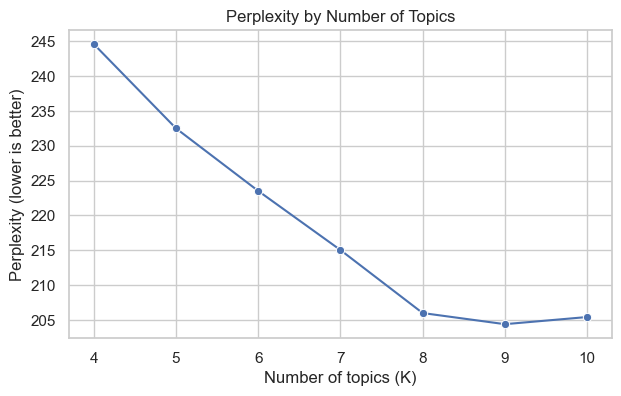

Best K: 9


In [148]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=score_df, x='k', y='perplexity', marker='o')
plt.title('Perplexity by Number of Topics')
plt.xlabel('Number of topics (K)')
plt.ylabel('Perplexity (lower is better)')
plt.show()

best_k = int(score_df.loc[score_df['perplexity'].idxmin(), 'k'])
print('Best K:', best_k)

In [149]:
# Fit final model
lda = LatentDirichletAllocation(
    n_components=best_k,
    random_state=42,
    learning_method='batch',
    max_iter=30,
)
W = lda.fit_transform(X)  # document-topic matrix
H = lda.components_        # topic-word matrix
terms = np.array(vectorizer.get_feature_names_out())

In [150]:
# Top words per topic
top_n = 12
topic_rows = []
for i, comp in enumerate(H):
    top_terms = terms[np.argsort(comp)[::-1][:top_n]]
    topic_rows.append({'topic': i, 'top_words': ', '.join(top_terms)})

topic_keywords_df = pd.DataFrame(topic_rows)
topic_keywords_df

,topic,top_words
0,0,"รัฐมนตรี, แต่งตั้ง, ตำแหน่ง, คณะ, กรรมการ, ตุล..."
1,1,"ประชุม, สมาชิก, สภา, วุฒิสภา, ร่าง, สภาผู้แทนร..."
2,2,"บุคคล, รัฐ, กฎหมาย, สิทธิ, ประชาชน, บัญญัติ, เ..."
3,3,"บังคับ, วรรค, พระมหากษัตริย์, ประกาศ, อนุโลม, ..."
4,4,"พระราชบัญญัติ, เล่ม, ตอน, ร่าง, หน้า, ราชกิจจา..."
5,5,"กฎหมาย, ราชการ, พิพากษา, ศาล, หน่วย, คดี, พิจา..."
6,6,"ประธาน, หน้าที่, แทน, องคมนตรี, รัฐสภา, ราชการ..."
7,7,"สมาชิก, เลือกตั้ง, สภาผู้แทนราษฎร, พรรค, เมือง..."
8,8,"รัฐธรรมนูญ, บัญญัติ, บท, รัฐมนตรี, ประกาศ, บัง..."


In [151]:
# Dominant topic per section + prevalence
df['dominant_topic'] = W.argmax(axis=1)

prevalence = (
    df['dominant_topic']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename('pct_sections')
    .reset_index()
)
prevalence = prevalence.rename(columns={prevalence.columns[0]: 'topic'})

prevalence


,topic,pct_sections
0,0,17.020824
1,1,15.618360
2,2,10.858479
3,3,10.178496
4,4,9.349766
5,5,9.647259
6,6,7.416065
7,7,12.579686
8,8,7.331067


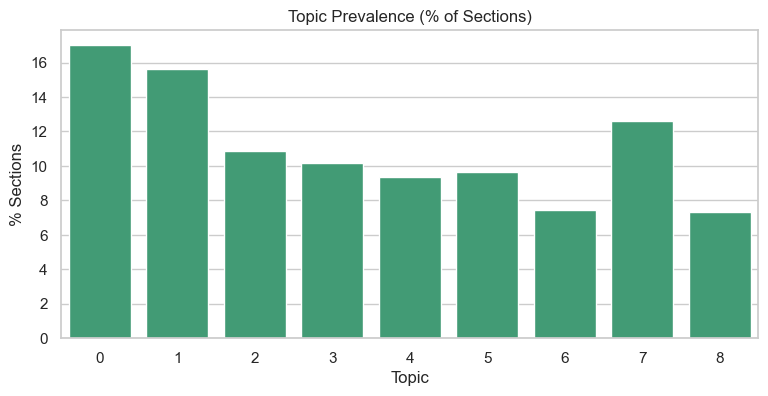

In [152]:
plt.figure(figsize=(9, 4))
sns.barplot(data=prevalence, x='topic', y='pct_sections', color='#3a7')
plt.title('Topic Prevalence (% of Sections)')
plt.xlabel('Topic')
plt.ylabel('% Sections')
plt.show()

In [153]:
# Topic trends over constitution year
topic_cols = [f'topic_{i}' for i in range(best_k)]
topic_prop = pd.DataFrame(W, columns=topic_cols)
topic_prop['year_th'] = df['year_th'].values
trend = topic_prop.groupby('year_th', as_index=False)[topic_cols].mean()

peak_rows = []
for col in topic_cols:
    idx = trend[col].idxmax()
    peak_rows.append({
        'topic': col,
        'peak_year_th': int(trend.loc[idx, 'year_th']),
        'peak_mean_proportion': float(trend.loc[idx, col]),
    })

peak_df = pd.DataFrame(peak_rows)
peak_df

,topic,peak_year_th,peak_mean_proportion
0,topic_0,2548,0.241873
1,topic_1,2557,0.334438
2,topic_2,2517,0.149029
3,topic_3,2535,0.245948
4,topic_4,2490,0.164660
5,topic_5,2550,0.185817
6,topic_6,2532,0.245495
7,topic_7,2554,0.352357
8,topic_8,2482,0.661080


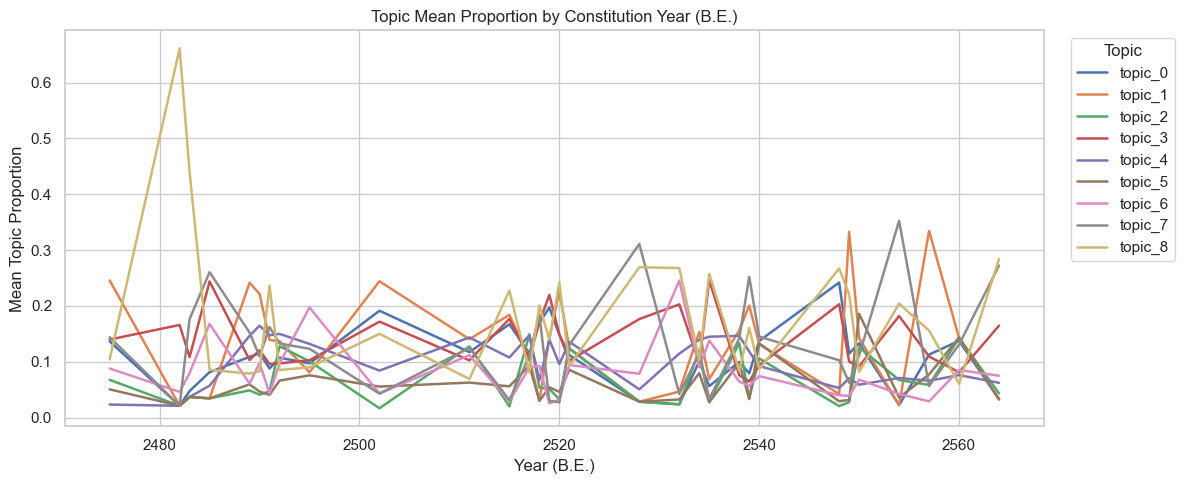

In [154]:
trend_long = trend.melt(id_vars='year_th', var_name='topic', value_name='mean_proportion')

plt.figure(figsize=(12, 5))
sns.lineplot(data=trend_long, x='year_th', y='mean_proportion', hue='topic', linewidth=1.8)
plt.title('Topic Mean Proportion by Constitution Year (B.E.)')
plt.xlabel('Year (B.E.)')
plt.ylabel('Mean Topic Proportion')
plt.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [155]:
# Optional: export section-level topic assignments
out = df[[
    'constitution_id', 'year_th', 'name_short', 'chapter_number', 'section_number',
    'dominant_topic'
]].copy()

for i in range(best_k):
    out[f'topic_{i}_prob'] = W[:, i]

out_path = '../../data/topic_assignments.csv'
out.to_csv(out_path, index=False)
print('Saved:', out_path)
out.head()

Saved: ../../data/topic_assignments.csv


,constitution_id,year_th,name_short,chapter_number,section_number,dominant_topic,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob
0,const_2475,2475,2475,0,1,2,0.010101,0.010103,0.420422,0.390920,0.010102,0.010102,0.010103,0.010102,0.128045
1,const_2475,2475,2475,0,2,3,0.010103,0.010102,0.010105,0.646658,0.010102,0.010104,0.010104,0.010101,0.282622
2,const_2475,2475,2475,1,3,3,0.013898,0.013892,0.013891,0.888863,0.013890,0.013892,0.013895,0.013890,0.013891
3,const_2475,2475,2475,1,4,3,0.055609,0.055556,0.055556,0.555462,0.055556,0.055556,0.055595,0.055556,0.055556
4,const_2475,2475,2475,1,5,0,0.525156,0.022222,0.022222,0.319281,0.022222,0.022224,0.022227,0.022223,0.022222


## Presentation Summary

This section builds a clean summary table with interpretable topic labels and key metrics (keywords, prevalence, peak year).

In [156]:
# Human-readable labels (can be edited after inspection)
topic_labels = {
    0: 'Cabinet & Appointments',
    1: 'Parliament Procedure',
    2: 'Rights & Liberties',
    3: 'Promulgation & Royal Acts',
    4: 'Royal Gazette / Enactment',
    5: 'Courts & Administration',
    6: 'Regency & Acting Authority',
    7: 'Elections & Representation',
    8: 'General Constitutional Clauses',
}

topic_summary = topic_keywords_df.merge(prevalence, on='topic', how='left')
topic_summary = topic_summary.merge(
    peak_df.assign(topic=peak_df['topic'].str.replace('topic_', '').astype(int)),
    on='topic',
    how='left'
)
topic_summary['topic_label'] = topic_summary['topic'].map(topic_labels).fillna('Unlabeled')
topic_summary['peak_year_ce'] = topic_summary['peak_year_th'] - 543
topic_summary = topic_summary[[
    'topic', 'topic_label', 'pct_sections', 'peak_year_th', 'peak_year_ce', 'peak_mean_proportion', 'top_words'
]].sort_values('pct_sections', ascending=False)

topic_summary


,topic,topic_label,pct_sections,peak_year_th,peak_year_ce,peak_mean_proportion,top_words
0,0,Cabinet & Appointments,17.020824,2548,2005,0.241873,"รัฐมนตรี, แต่งตั้ง, ตำแหน่ง, คณะ, กรรมการ, ตุล..."
1,1,Parliament Procedure,15.618360,2557,2014,0.334438,"ประชุม, สมาชิก, สภา, วุฒิสภา, ร่าง, สภาผู้แทนร..."
7,7,Elections & Representation,12.579686,2554,2011,0.352357,"สมาชิก, เลือกตั้ง, สภาผู้แทนราษฎร, พรรค, เมือง..."
2,2,Rights & Liberties,10.858479,2517,1974,0.149029,"บุคคล, รัฐ, กฎหมาย, สิทธิ, ประชาชน, บัญญัติ, เ..."
3,3,Promulgation & Royal Acts,10.178496,2535,1992,0.245948,"บังคับ, วรรค, พระมหากษัตริย์, ประกาศ, อนุโลม, ..."
5,5,Courts & Administration,9.647259,2550,2007,0.185817,"กฎหมาย, ราชการ, พิพากษา, ศาล, หน่วย, คดี, พิจา..."
4,4,Royal Gazette / Enactment,9.349766,2490,1947,0.164660,"พระราชบัญญัติ, เล่ม, ตอน, ร่าง, หน้า, ราชกิจจา..."
6,6,Regency & Acting Authority,7.416065,2532,1989,0.245495,"ประธาน, หน้าที่, แทน, องคมนตรี, รัฐสภา, ราชการ..."
8,8,General Constitutional Clauses,7.331067,2482,1939,0.661080,"รัฐธรรมนูญ, บัญญัติ, บท, รัฐมนตรี, ประกาศ, บัง..."


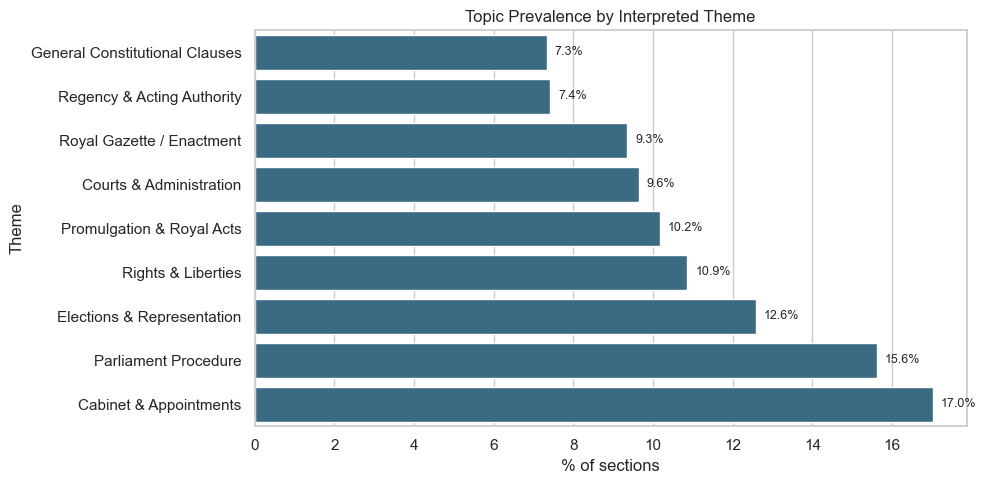

In [157]:
plt.figure(figsize=(10, 5))
plot_df = topic_summary.sort_values('pct_sections', ascending=True)
ax = sns.barplot(data=plot_df, x='pct_sections', y='topic_label', color='#2f6f8f')
ax.set_title('Topic Prevalence by Interpreted Theme')
ax.set_xlabel('% of sections')
ax.set_ylabel('Theme')
for i, v in enumerate(plot_df['pct_sections']):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


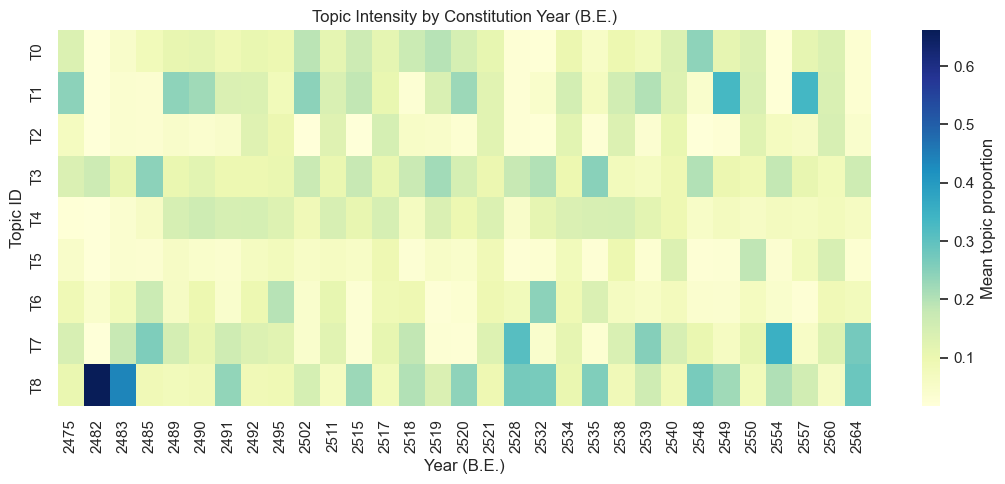

In [158]:
# Heatmap of topic intensity over time
heat = trend.set_index('year_th')
heat.columns = [c.replace('topic_', 'T') for c in heat.columns]

plt.figure(figsize=(11, 5))
sns.heatmap(heat.T, cmap='YlGnBu', cbar_kws={'label': 'Mean topic proportion'})
plt.title('Topic Intensity by Constitution Year (B.E.)')
plt.xlabel('Year (B.E.)')
plt.ylabel('Topic ID')
plt.tight_layout()
plt.show()
